## 1. Import Libraries

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import make_moons, make_blobs
from matplotlib.colors import ListedColormap
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np


## 2. Generate The Data

In [4]:
X,y = make_moons(n_samples=1000, noise=0.1, random_state=0)

Convert the Data into Dataframe

In [5]:
df = pd.DataFrame(X, columns=['x1', 'x2'])
df["y"] = y

so we have 2 features "x1" and "x2" and target "y"

In [6]:
df.describe()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1000 non-null   float64
 1   x2      1000 non-null   float64
 2   y       1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [7]:
df

,x1,x2,y
0,2.042715,0.518124,1
1,1.720337,-0.132338,1
2,-0.263867,0.763826,0
3,-0.098035,0.180082,1
4,0.478476,-0.398778,1
...,...,...,...
995,1.548609,-0.135898,1
996,0.312739,0.958280,0
997,0.338237,-0.430999,1
998,0.126943,0.099663,1


## 3. Visualize _"feature with label"_

we see the classification shape

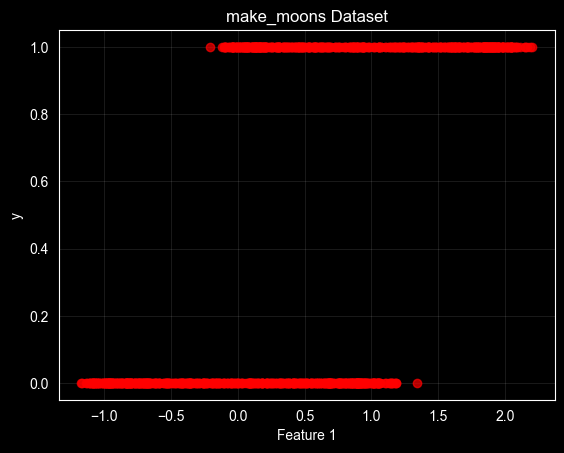

In [8]:
plt.scatter(df["x1"], y, c="red", alpha=0.7)
plt.xlabel("Feature 1")
plt.ylabel("y")
plt.title("make_moons Dataset")
plt.grid(True,alpha=0.1)
plt.show()

## 4. Visualize _"feature 1 with feature 2"_

The visualization is a 2D scatter plot where:
* Each point represents one data sample
* X-axis → Feature 1
* Y-axis → Feature 2
* Color → Class label (0 or 1)

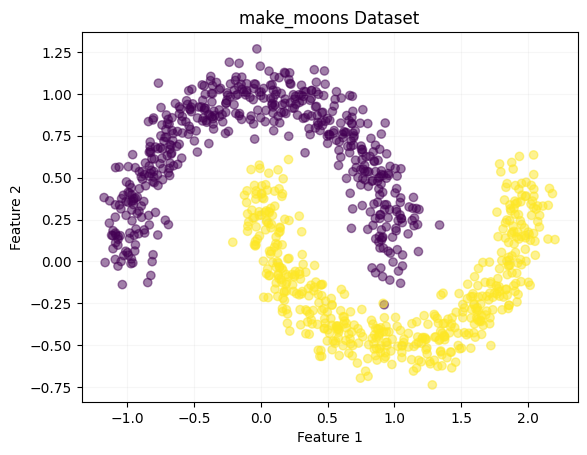

In [9]:
plt.style.use("mpl20")
plt.scatter(df["x1"], df["x2"], c=y, alpha=0.5)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("make_moons Dataset")
plt.grid(True,alpha=0.1)
plt.show()

## 5. Splitting The Data

In [10]:
X_train, X_test, y_train, y_test = train_test_split(df[["x1","x2"]], df["y"], test_size=0.2, random_state=42)

## 6. Scaling Features for KNN

In [11]:
scaleModel = StandardScaler()
X_train = scaleModel.fit_transform(X_train)
X_test = scaleModel.transform(X_test)

## 7. Training the KNN model

In [12]:
# n_neighbors => K
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

Make new DataFrame have only test value to see the **"Actual value"** and **"Prediction"**

In [13]:
test = pd.DataFrame(X_test, columns=["x1", "x2"])
test["y"] = y_test.values
test["y_pred"] = y_pred

In [14]:
test.info()
test

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      200 non-null    float64
 1   x2      200 non-null    float64
 2   y       200 non-null    int64  
 3   y_pred  200 non-null    int64  
dtypes: float64(2), int64(2)
memory usage: 6.4 KB


,x1,x2,y,y_pred
0,0.605230,0.498592,0,0
1,0.460055,0.488878,0,0
2,-0.335557,-0.647992,1,1
3,-0.086619,1.304340,0,0
4,-1.326668,0.588040,0,0
...,...,...,...,...
195,-0.136032,-1.110251,1,1
196,0.514938,0.165139,0,0
197,-0.542180,0.384509,1,1
198,1.199250,-0.930394,1,1


## 8. Plotting

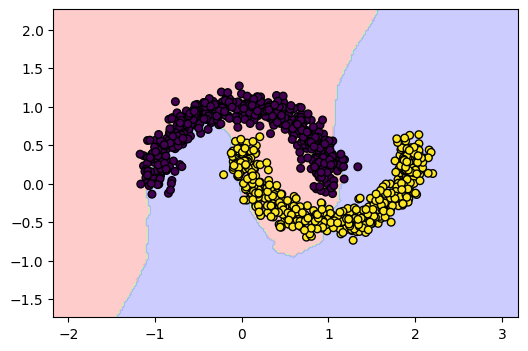

In [17]:
# Plot decision boundary
h = .02
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 4))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF']), alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', s=30)
plt.show()

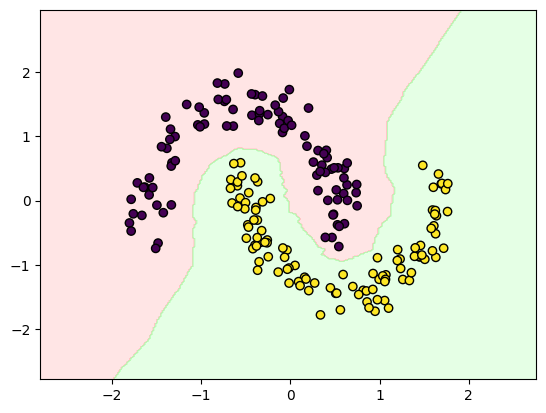

In [157]:
# Plot decision boundary
h = .02
# 1. Creating the mesh grid
x_min = test["x1"].min() - 1
x_max = test["x1"].max() + 1
y_min = test["x2"].min() - 1
y_max = test["x2"].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h))
# 2. Predicting class for every grid point
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
# 3. Drawing the decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#FFAAAA', '#AAFFAA']))

plt.scatter(test["x1"], test["x2"], c=y_test, edgecolor='k')